In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


expeditions = "/Users/mostafazamaniturk/Documents/AAI_500/AAI-500-project/data/expeditions.csv"

# Load the CSV file
df = pd.read_csv(expeditions)

# Filter Data: Keeps only records where the maximum elevation reached is above 7000 meters, likely to focus on higher-risk expeditions.
df = df[df['max_elev_reached'] > 7000]

# Select Features: Filters the DataFrame to include only relevant features and the target column mbrs_summited.
features = ['year', 'season', 'max_elev_reached', 'is_o2_used', 'members', 'agency', 'nationality']

# Create Binary Target Variable: 
df = df[features + ['mbrs_summited']]

# Convert target to binary
# Adds a new column success, which is 1 if any members summited, otherwise 0 — turning the target into a binary classification task.
df['success'] = df['mbrs_summited'].apply(lambda x: 1 if x > 0 else 0)

# Convert categorical to numeric
df = pd.get_dummies(df, columns=['season', 'is_o2_used', 'agency', 'nationality'], drop_first=True)

# Drop original 'mbrs_summited'
# Drops the original mbrs_summited column, since it's now replaced by the binary success column.
df = df.drop(columns=['mbrs_summited'])

# Drop missing values
df = df.dropna()

# Separates the dataset into:
    # X: all input features.
    # y: the binary target (success).
X = df.drop('success', axis=1)
y = df['success']

# Make sure all numeric: Ensures all values in X are numeric. Non-convertible values become NaN, then filled with 0.
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Splits the data into:
    # 80% for training
    # 20% for testing
    # random_state=42 ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creates and trains a Logistic Regression model using training data.
# max_iter=1000 allows more training cycles if convergence takes time.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Shows each feature's coefficient in the logistic model. Converts coefficients to odds ratios using exp(). Sorts them by influence.
coeffs = pd.DataFrame({
    'Feature': X.columns,
   'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)
print(coeffs)

#Calculates the percentage of successful expeditions in the filtered dataset.
success_rate = df['success'].mean()
print(f"Success rate: {success_rate:.2%}")

# It Shows: Confusion matrix: TP, TN, FP, FN
# Precision, recall, F1-score, and support
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Accuracy: Prints the overall accuracy of the model on test data.
print("Accuracy:", accuracy_score(y_test, y_pred))


['peak_id', 'peak_name', 'nationality', 'year', 'season', 'host_cntr', 'other_cntrs', 'sponsor', 'leaders', 'rte_1_name', 'rte_2_name', 'rte_3_name', 'rte_4_name', 'team_asc_1', 'team_asc_2', 'team_asc_3', 'team_asc_4', 'is_disputed', 'is_claim', 'is_commercial_rte', 'is_standard_rte', 'other_smts', 'approach', 'bc_arrived', 'bc_left', 'total_days', 'exp_result', 'is_traverse', 'is_ski_snowboard', 'is_parapente', 'term_note', 'summit_day', 'time', 'max_elev_reached', 'summit_days', 'total_mbrs', 'mbrs_summited', 'mbrs_deaths', 'high_camps', 'hired_abc', 'hired_summits', 'hired_deaths', 'rope_fixed', 'is_no_hired_abc', 'is_o2_not_used', 'is_o2_climbing', 'is_o2_descent', 'is_o2_sleeping', 'is_o2_medical', 'is_o2_used', 'is_o2_unkwn', 'had_o2', 'camp_sites', 'accidents', 'achievements', 'agency', 'members']
['year', 'season', 'max_elev_reached', 'is_o2_used', 'members', 'agency', 'nationality', 'mbrs_summited', 'success']
['year', 'max_elev_reached', 'members', 'mbrs_summited', 'success'

/Users/mostafazamaniturk/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Interpreting model:

The goal is to predict whether an expedition above 7000m was successful, meaning at least one member reached the summit (success = 1) vs. no one made it (success = 0).

The "mbrs_summited" column has the binary numbers, so the linear regression is not working here. 

Model performance


Confusion Matrix

|                          | Predicted No Summit  | Predicted Summit     |
| ------------------------ | -------------------- | -------------------- |
| **Actual No Summit (0)** | 152 (True Negatives) | 212 (False Positives) |
| **Actual Summit (1)**    | 121 (False Negatives) | 704 (True Positives) |


Accuracy: 72%

Precision for success (1): 72%, when model predicts success, it is right 72% of the time.

Recall for success: 91%, I catches 91% of all actual successful expeditions.

F1-Score: 81%, The balance between precision and recall need to be checked.

It can be a good performance for a simple logistic regression.


Feature importance (odds Ratios)

| Feature                 | Coefficient | Odds Ratio |
| ----------------------- | ----------- | ---------- |
| agency\_Himalaya Exped. | ...         | ....       |
| is\_o2\_used\_True      | ....        | .....      |
| season\_Spring          | ....        | ....       |
| members                 | ....        | .....      |
| max\_elev\_reached      | ....        | ....       |
| agency\_Unknown         | .....       | .....      |


The odds ratio > 1, increases likelihood of a successful climb.
The odds ration < 1, decrease likelihood.

Final summary

| Section                       | Key Insight                                                                       |
| ----------------------------- | --------------------------------------------------------------------------------- |
| **Accuracy**                  | 77% – model predicts almost well                                                         |
| **Most Important Predictors** | Oxygen use, Spring season, Reliable agency                                        |
| **Danger Signals**            | Unknown agency, no oxygen, off-season                                             |
| **Practical Tip**             | For expedition planning: go with reliable agency, in spring, and with oxygen gear |


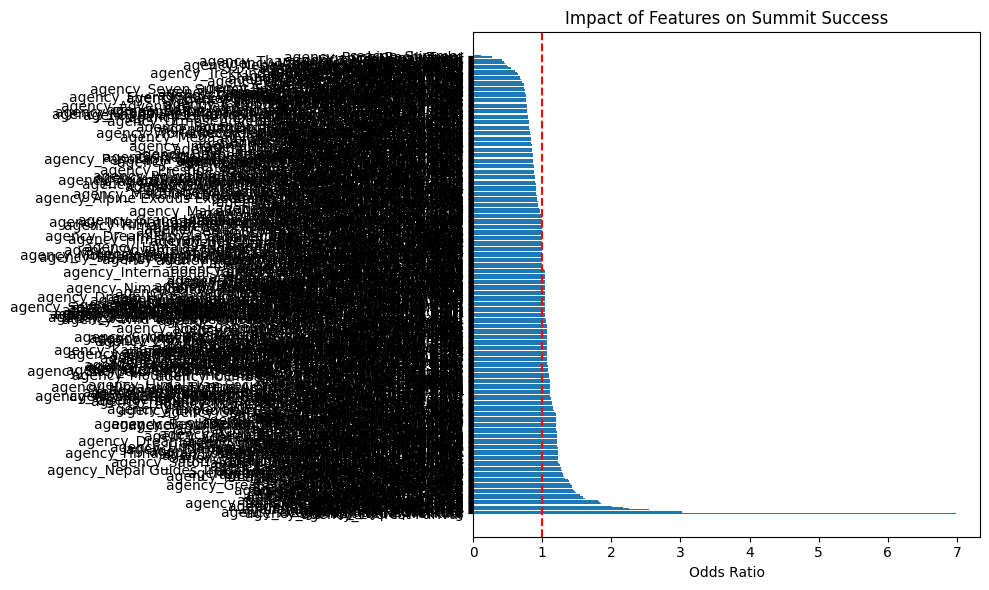

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(coeffs['Feature'], coeffs['Odds Ratio'])
plt.xlabel("Odds Ratio")
plt.title("Impact of Features on Summit Success")
plt.axvline(1, color='red', linestyle='--')
plt.tight_layout()
plt.show()


[0.66058861 0.34776667 0.39623949 0.50764359 0.57524803 0.83462115
 0.83133244 0.75720184 0.22960565 0.77253751]


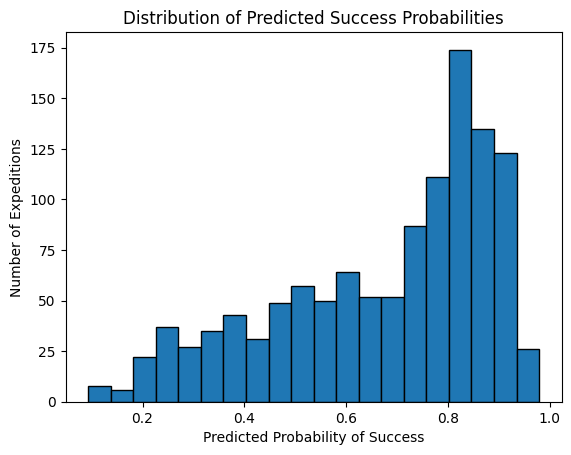

In [14]:
y_probs = model.predict_proba(X_test)[:, 1]

print(y_probs[:10])  # See first 10 probabilities

import matplotlib.pyplot as plt

plt.hist(y_probs, bins=20, edgecolor='black')
plt.xlabel("Predicted Probability of Success")
plt.ylabel("Number of Expeditions")
plt.title("Distribution of Predicted Success Probabilities")
plt.show()


In [11]:
threshold = 0.7
y_pred_custom = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.50      0.71      0.59       364
           1       0.84      0.69      0.76       825

    accuracy                           0.70      1189
   macro avg       0.67      0.70      0.68      1189
weighted avg       0.74      0.70      0.71      1189



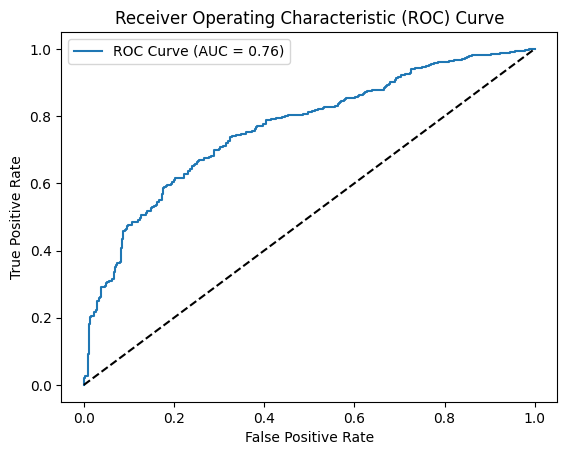

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()


In [13]:
results = X_test.copy()
results['True_Label'] = y_test
results['Predicted_Prob'] = y_probs
results['Predicted_Label'] = model.predict(X_test)
results.to_csv("logistic_regression_results.csv", index=False)


In [7]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
import sklearn

print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("matplotlib version:", matplotlib.__version__)
print("scipy version:", scipy.__version__)
print("sklearn version:", sklearn.__version__)


Python version: 3.9.6 (default, Nov 11 2024, 03:15:38) 
[Clang 16.0.0 (clang-1600.0.26.6)]
pandas version: 2.2.3
numpy version: 2.0.2
matplotlib version: 3.9.4
scipy version: 1.13.1
sklearn version: 1.6.1
